In [2]:
# Load Parquet (County Regression Data), preview, list columns, and show descriptives

from pathlib import Path
import pandas as pd

# --- PATH ---
pq_path = Path('/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/Parquet of Data/BLS_IRS_fossil_working.parquet')

# --- LOAD ---
df = pd.read_parquet(pq_path)
print(f"Loaded: {pq_path.name}  |  Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

list()

Loaded: BLS_IRS_fossil_working.parquet  |  Shape: 275,968 rows × 54 columns


[]

In [3]:
# ============================================================
# Build df_bal2: All-industries & sample==1 → 2005–2012 → balanced panel
# One row per county–year for the analysis variables
# Authors already trimmed off smallest 2% of counties in their dataset
# ============================================================

import numpy as np
import pandas as pd

# -----------------------
# 0) Config
# -----------------------
PATH = "/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/Parquet of Data/BLS_IRS_fossil_working.parquet"
WINDOW = (2005, 2012)  # main analysis window
vars_county = [
    "newvalue_capita",
    "d_wages_capita",
    "d_irswages_capita",
    "d_irsotherinc_capita",
    "d_irsagi_capita",
]

# -----------------------
# 1) Load
# -----------------------
df = pd.read_parquet(PATH).copy()
print(f"Loaded rows: {len(df):,}") # Prints number of raw rows for quick check

# Normalize year dtype early: Coerces year to numeric nullable type Int65 to prevent filtering bugs later
if "year" not in df.columns:
    raise ValueError("Input data has no 'year' column.")
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

# -----------------------
# 2) All-industries filter
# -----------------------
# The regressions are run on All-industry totals in the paper. Many source files have 
# multiple industry rows per county year; this step standardizes to the total row.

mask_all = pd.Series(False, index=df.index) # Builds a boolean mask for "All Industries"

# If an industr text column exists, it selects row where that string contains "all" or "total"
if "industry" in df.columns:
    ind = df["industry"].astype(str).str.lower()
    mask_all = ind.str.contains("all") | ind.str.contains("total")

# Else if an id column exists, it uses id==1
if not mask_all.any() and "id" in df.columns:
    mask_all = df["id"] == 1

# Else if an id_industry exists, it uses id_industry==0
if not mask_all.any() and "id_industry" in df.columns:
    mask_all = df["id_industry"] == 0

# If none are found, it raises an error
if not mask_all.any():
    raise ValueError(
        "Could not identify 'All industries' rows via 'industry', 'id', or 'id_industry'."
    )

df = df.loc[mask_all].copy() # Applies mask and prints rows to check
print(f"After All-industries filter: {len(df):,} rows")

# -----------------------
# 3) Sample==1 (paper’s analysis sample), if available 
# -----------------------
if "sample" in df.columns:
    before = len(df)
    df = df.loc[df["sample"] == 1].copy()
    print(f"After sample==1: {len(df):,} rows (from {before:,})")
else:
    print("Column 'sample' not found — skipping sample==1 filter.")

# -----------------------
# 4) Restrict to 2005–2012
# -----------------------
df = df.loc[df["year"].between(WINDOW[0], WINDOW[1])].copy()
print(f"After year window {WINDOW[0]}–{WINDOW[1]}: {len(df):,} rows")

# -----------------------
# 5) Enforce a balanced panel over the remaining years
#    (Every county must appear in all detected years)
# -----------------------
# Finds distinct years left after your filters and sets T = number of years (8), 
# computes how many distinct years each county (fips) appears,
# and keeps only counties appearing in all T=8 years.

years = sorted([int(y) for y in df["year"].dropna().unique()])
if not years:
    raise ValueError("No years remain after filtering.")
T = len(years)

nyears_by_fips = (
    df[["fips", "year"]]
    .drop_duplicates()
    .groupby("fips")["year"]
    .nunique()
)
balanced_fips = nyears_by_fips.index[nyears_by_fips == T]
df_bal = df[df["fips"].isin(balanced_fips)].copy()

print(f"Balanced years detected: {years[0]}–{years[-1]} (T={T})")
print(f"Counties in balanced panel: {df_bal['fips'].nunique():,}")
print(f"County–years in balanced panel (pre de-dup): {len(df_bal):,}")

# -----------------------
# 6) Reduce to one row per county–year for the analysis variables
#    (Different sources sometimes duplicate rows; keep the first)
# -----------------------
# Still might be multiple rows per county year (residual industry specifics)
# so drop_duplicates guarantees a single analysis row per county year... just to be safe!
present = [v for v in vars_county if v in df_bal.columns]
if not present:
    raise ValueError("None of the requested analysis variables are in the data.")

df_bal2 = (
    df_bal[["fips", "year"] + present]
    .drop_duplicates(subset=["fips", "year"])    # ensure unique county–year
    .sort_values(["fips", "year"])
    .copy()
)

print(f"County–years (after de-duplicating): {len(df_bal2):,}")
print("Variables present:", present)

# df_bal2 is a clean, balanced, all-industries, sample==1, 2005-2012 county year dataset containing
# only the variables we need to run county level regression!

Loaded rows: 275,968
After All-industries filter: 34,496 rows
After sample==1: 27,702 rows (from 34,496)
After year window 2005–2012: 24,624 rows
Balanced years detected: 2005–2012 (T=8)
Counties in balanced panel: 3,078
County–years in balanced panel (pre de-dup): 24,624
County–years (after de-duplicating): 24,624
Variables present: ['newvalue_capita', 'd_wages_capita', 'd_irswages_capita', 'd_irsotherinc_capita', 'd_irsagi_capita']


In [4]:
# ================================================
# OLS with COUNTY & YEAR FIXED EFFECTS (2-way FE)
# ================================================
# Model estimated:
#   Δy_it = β1 * newvalue_capita_it + β2 * newvalue_capita_{i,t-1}
#         + α_i (county FE) + ω_t (year FE) + ε_it

# Notes on units:
# - newvalue_capita is in **MILLIONS of 2014 USD per person**.
#   So a 0.001 change in the regressor = **$1,000 per person**.
# - Outcomes (d_irswages_capita, d_wages_capita) are **USD per person** (changes).

# Inference:
# - We use two-way clustered standard errors (by county and by year)
#   to allow serial correlation within counties and common shocks within a year.

# Requirements: `pip install linearmodels`
# Data expected: balanced county-year panel in `df_bal2`.
# =================================================

import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS


# ---------- 1) Build a clean panel for FE regression ----------
use = df_bal2.copy() # Use the balanced (2005–2012) all-industries panel

# Keep only columns needed for this spec (IDs, shock, outcomes)
need = ["fips", "year", "newvalue_capita", "d_irswages_capita", "d_wages_capita", "d_irsotherinc_capita"]
use = use[need].dropna(subset=["fips", "year"]).copy() # redundant, but harmless

# Be strict about numeric types (ensures none of these are strings after import/merge)
for c in ["newvalue_capita", "d_irswages_capita", "d_wages_capita", "d_irsotherinc_capita"]:
    use[c] = pd.to_numeric(use[c], errors="coerce")

# Restrict to paper's main window; adjust if you needed
use = use[use["year"].between(2005, 2012)] #r edundant, but harmless

# Create the within-county lag of the shock (t−1) used in the model
use = use.sort_values(["fips", "year"])
use["L1_newvalue_capita"] = use.groupby("fips")["newvalue_capita"].shift(1)

#  Set a MultiIndex (county, year) so PanelOLS recognizes the panel structure
panel = use.set_index(["fips", "year"]) # Tells the model its panel data basically

# Common regressor matrix used by both outcomes
X = panel[["newvalue_capita", "L1_newvalue_capita"]]

# ---------- 2) Helper to run one FE regression and print a compact summary ----------
def run_fe(y_col: str, label: str):
    """
    y_col : name of the outcome column (e.g., 'd_irswages_capita')
    label : pretty label used in prints
    """
    # Joins the chosen outcome with regressors, then drop rows with any missing values
    df = panel[[y_col]].join(X).dropna()

    # Simple counts for context and sanity check
    n_entities = df.index.get_level_values(0).nunique()  # unique counties
    n_years    = df.index.get_level_values(1).nunique()  # unique years

    # Two-way FE model: county FE (entity_effects) + year FE (time_effects)
    mod = PanelOLS(
        df[y_col],                                        # Δ outcome (USD/person)
        df[["newvalue_capita", "L1_newvalue_capita"]],    # shock at t and t−1
        entity_effects=True,   # α_i  (absorbs time-invariant county traits like geology, long-run industrial mix, etc.)
        time_effects=True      # ω_t  (absorbs year shocks like recessions/booms)
    )

    # Inference: Fit with **two-way clustered** SEs: cluster on county and on year
    res = mod.fit(
        cov_type="clustered",
        cluster_entity=True,   # serial correlation within a county over time
        cluster_time=True      # spatial correlation across counties within a year
    )

    # Header
    print(f"\n=== OLS FE (county & year) — {label} ===")
    print(f"Observations (county–years): {res.nobs:,}  |  Counties: {n_entities:,}  |  Years: {n_years}")

    # Compact coefficient table (focus on the two shock terms)
    out = pd.DataFrame({
        "Coefficients": res.params,                 # β estimates
        "SE (2-way Clustered)": res.std_errors,
        "t-stat": res.tstats,
        "p-value": res.pvalues
    })
    # Only display current and lagged shock rows; round for readability
    display(out.loc[["newvalue_capita", "L1_newvalue_capita"]].round(4))

    # R² diagnostics:
    #  - within: share of variance explained **after** removing county & year means (most informative with FE)
    #  - overall: includes fixed effects (often much larger)
    
    r2w = getattr(res, "rsquared_within", np.nan)
    r2o = getattr(res, "rsquared", np.nan)
    print(f"R2 (within): {r2w:.3f} | R2 (overall): {r2o:.3f}")

    # Tip on interpretation:
    # Multiply a coefficient by 0.001 to get the effect **per $1,000/person** of new production.
    # Example: coef=16890  →  16890 * 0.001 = $16.89 per person.

    return res

# ---------- 3) Run both outcomes ----------
# IRS = place of residence (individual tax data); tends to show more reversion
res_irs = run_fe("d_irswages_capita", "IRS wage income per person (Δ)")

# BLS = place of work (establishment payroll data); often contemporaneous and larger
res_bls = run_fe("d_wages_capita",    "BLS wage bill per person (Δ)")

# IRS Other = royalties and nonwage business income such as rental income
res_other = run_fe("d_irsotherinc_capita",
                   "IRS other income (royalties & nonwage business) per person (Δ)")


=== OLS FE (county & year) — IRS wage income per person (Δ) ===
Observations (county–years): 21,546  |  Counties: 3,078  |  Years: 7


,Coefficients,SE (2-way Clustered),t-stat,p-value
newvalue_capita,16890.9842,5294.9815,3.1900,0.0014
L1_newvalue_capita,-9826.7002,4846.5404,-2.0276,0.0426


R2 (within): 0.007 | R2 (overall): 0.007

=== OLS FE (county & year) — BLS wage bill per person (Δ) ===
Observations (county–years): 21,546  |  Counties: 3,078  |  Years: 7


,Coefficients,SE (2-way Clustered),t-stat,p-value
newvalue_capita,33956.5539,10430.4275,3.2555,0.0011
L1_newvalue_capita,4717.8850,11338.8965,0.4161,0.6774


R2 (within): 0.042 | R2 (overall): 0.044

=== OLS FE (county & year) — IRS other income (royalties & nonwage business) per person (Δ) ===
Observations (county–years): 21,546  |  Counties: 3,078  |  Years: 7


,Coefficients,SE (2-way Clustered),t-stat,p-value
newvalue_capita,64093.9926,7709.7983,8.3133,0.0
L1_newvalue_capita,-43873.2155,5781.1313,-7.5890,0.0


R2 (within): 0.011 | R2 (overall): 0.010


In [5]:
import numpy as np
import pandas as pd

# 0) Make sure df_bal2 (balanced, all-industries, sample==1, 2005–2012) is already in memory.

# 1) Load the raw file just to pull the IV column (no *_ins2)
PATH = "/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/Parquet of Data/BLS_IRS_fossil_working.parquet"
raw = pd.read_parquet(PATH)

# Keep only the regression window and the single IV column
keep_cols = ["fips", "year", "newvalue_capita_ins"]
raw = raw.loc[raw["year"].between(2005, 2012), keep_cols].copy()

if "newvalue_capita_ins" not in raw.columns:
    raise ValueError("Expected 'newvalue_capita_ins' in the raw file but did not find it.")

# 2) Collapse to one value per county–year (if multiple industry rows exist)
iv_wide = (
    raw.groupby(["fips", "year"], as_index=False)["newvalue_capita_ins"]
       .max()  # pick a non-missing if duplicates exist
)

# 3) Merge IV into your balanced panel
df_bal3 = df_bal2.merge(iv_wide, on=["fips", "year"], how="left")
# left keeps all rows from df_bal2. If instrument is missing for a county-year, NaN shows, but that is dropped later.

# 4) Create lags (within county) for the endogenous regressor and the IV
df_bal3 = df_bal3.sort_values(["fips", "year"]).copy()

# Ensure numeric: protects from string/object dtypes sneaking in
for c in ["newvalue_capita", "newvalue_capita_ins"]:
    if c in df_bal3.columns:
        df_bal3[c] = pd.to_numeric(df_bal3[c], errors="coerce")

df_bal3["L1_newvalue_capita"]     = df_bal3.groupby("fips")["newvalue_capita"].shift(1)
df_bal3["L1_newvalue_capita_ins"] = df_bal3.groupby("fips")["newvalue_capita_ins"].shift(1)

# 5) Quick sanity checks
print(f"Rows in df_bal2: {len(df_bal2):,}  →  Rows in df_bal3: {len(df_bal3):,}")
print("Non-missing IVs (current):", int(df_bal3["newvalue_capita_ins"].notna().sum()))
print("Non-missing IVs (lag):    ", int(df_bal3["L1_newvalue_capita_ins"].notna().sum()))


# newvalue_capita = endogenous regressor (Millions of 2014 USD/person).
# newvalue_capita_ins = the instrument (pre-determined geology × timing).
# Lags let you match the paper’s dynamic specification that includes current and lagged shocks, both instrumented.
# By merging onto df_bal2, you preserve the exact balanced sample you used for OLS, making IV/OLS directly comparable.

Rows in df_bal2: 24,624  →  Rows in df_bal3: 24,624
Non-missing IVs (current): 24624
Non-missing IVs (lag):     21546


In [6]:
# =============================================================================
# County-level IV (2SLS) with county & year fixed effects (absorbed by demeaning)
# Data  : df_bal3  (one row per county–year; e.g., 2005–2012; already balanced)
# Endog : newvalue_capita (current) and L1_newvalue_capita (lag)
# IVs   : newvalue_capita_ins (current) and L1_newvalue_capita_ins (lag)
# Y     : d_irswages_capita  or  d_wages_capita   (per person, USD, changes)
# FE    : County & Year FE absorbed via two-way demeaning (no dummy explosion)
# SEs   : Two-way clustered by county and by year
#
# Units: X variables are in MILLIONS of 2014 USD per person.
#        Multiply β by 0.001 → $/person per $1,000/person of new production.
# Requires: pip install linearmodels
# =============================================================================

import numpy as np
import pandas as pd
from linearmodels.iv import IV2SLS

# Instrument both current & lag shocks (paper’s main spec).
# If true, you instrument both current and lagged shocks; if false
# you instrument current only and include lag as an ordinary (exogeneous) control
INSTRUMENT_LAG = True 

# ---- 0) Sanity checks on df_bal3 ---------------------------------------------
need = [
    "fips", "year",
    "newvalue_capita", "L1_newvalue_capita",
    "newvalue_capita_ins", "L1_newvalue_capita_ins",
    "d_irswages_capita", "d_wages_capita", "d_irsotherinc_capita",
]
missing = [c for c in need if c not in df_bal3.columns]
if missing:
    raise ValueError(f"df_bal3 is missing required columns: {missing}")

# MultiIndex for clear county–year alignment downstream
panel = df_bal3.set_index(["fips", "year"]).copy()

# ---- 1) Two-way demeaning helper (absorbs county & year FE) for Y,X, and Z ------------------
def twoway_demean(df_in: pd.DataFrame) -> pd.DataFrame:
    by_cty = df_in.groupby(level=0).transform("mean")  # county mean
    by_yr  = df_in.groupby(level=1).transform("mean")  # year mean
    grand  = df_in.mean()                              # overall mean
    return df_in - by_cty - by_yr + grand

# Abosrbs fixed effects without creating thousands of dummies: it does this by subtracting each
# county mean and year mean, adds back the grand mean so variables aren't all centered at zero overall.

# by_cty: county specific averages across years -> wipes out all time invariant county effects (county FE)
# by_yr: year average across counties -> wipes out common year shocks (year FE)
# Adds back the grand mean to correct double subtracting.

# Algebraically equivalent to including county and year dummies and partialling them out.

# ---- 2) Runner: IV spec for a given outcome ----------------------------------
def run_iv_fe(y_col: str, label: str, instrument_lagged: bool = INSTRUMENT_LAG):
    """
    y_col : 'd_irswages_capita' or 'd_wages_capita'
    label : pretty label in prints
    instrument_lagged : True = instrument current & lag; False = only current.
    """
    # a) Pull only what we need and drop true missings (zeros are fine)
    cols = [y_col,
            "newvalue_capita", "L1_newvalue_capita",
            "newvalue_capita_ins", "L1_newvalue_capita_ins"]
    d = panel[cols].dropna().copy()
    if d.empty:
        print(f"[{label}] No rows after aligning y, X, Z. Check IV coverage/lags.")
        return None

    # b) Build endogenous X and instrument Z lists
    endog_cols = ["newvalue_capita"]
    instr_cols = ["newvalue_capita_ins"]
    if instrument_lagged:
        endog_cols.append("L1_newvalue_capita")
        instr_cols.append("L1_newvalue_capita_ins")

    # If instrument_lag = true, both current and lag are treated as endogenous and each given its own instrument

    # c) Absorb FE by two-way demeaning (apply to y, X, Z)
    dm = twoway_demean(d[[y_col] + endog_cols + instr_cols])
    y = dm[y_col]
    X = dm[endog_cols]
    Z = dm[instr_cols]
    exog = None  # Exog is where you put exog controls and a constant. After two-way demeaning, a constant is
    # identically zero (collinear), and we have no other exog controls to include, so NONE. 

    # First subset d to exactly the columns used in the IV regressions: outcomes, endog regressors, instruments.
    # Then pass subset into twoway_demean, which applies the FEs transformation to every column.
    # dm is a df with the same index (cty, yr), and the same cols, but all variables have cty and yr effects stripped out.


    # d) Two-way clustered SEs: cluster by county and year
    idx = d.index
    clusters = np.column_stack([
        idx.get_level_values(0).to_numpy(),  # fips
        idx.get_level_values(1).to_numpy()   # year
    ])

    # e) 2SLS (first & second stage handled internally)
    res = IV2SLS(dependent=y, exog=exog, endog=X, instruments=Z).fit(
        cov_type="clustered",
        clusters=clusters
    )

    # f) Compact table
    names = endog_cols
    table = pd.DataFrame({
        "coef":       [res.params[n]     for n in names],
        "se (2-way)": [res.std_errors[n] for n in names],
        "t":          [res.tstats[n]     for n in names],
        "p":          [res.pvalues[n]    for n in names]
    }, index=names).round(4)

    nobs   = int(res.nobs)
    n_cty  = idx.get_level_values(0).nunique()
    n_year = idx.get_level_values(1).nunique()
    print(f"\n=== IV 2SLS (county & year FE absorbed) — {label} ===")
    print(f"Obs (county–years): {nobs:,}  |  Counties: {n_cty:,}  |  Years: {n_year}")
    try:
        display(table)
    except NameError:
        print(table.to_string())

    # g) First-stage diagnostics (if exposed by your linearmodels version)
    fs = getattr(res, "first_stage", None)
    if isinstance(fs, dict) and fs:
        print("First-stage diagnostics:")
        for k, fsr in fs.items():
            fobj = getattr(fsr, "f_statistic", None) or getattr(fsr, "f_stat", None)
            f_txt = (f"{getattr(fobj, 'stat', np.nan):.1f} (p={getattr(fobj, 'pval', np.nan):.4f})"
                     if fobj else "n/a")
            pr2 = getattr(fsr, "partial_rsquared", None)
            pr2s = f"{pr2:.3f}" if isinstance(pr2, (float, int, np.floating)) else "n/a"
            print(f"  {k}: partial F = {f_txt} | partial R² = {pr2s}")

    print("Interpretation: β × 0.001 = $/person per $1,000/person of new production.\n")
    return res

# ---- 3) Run both outcomes -----------------------------------------------------
res_iv_irs = run_iv_fe("d_irswages_capita", "IRS wages per person (Δ)")
res_iv_bls = run_iv_fe("d_wages_capita",    "BLS wage bill per person (Δ)")
res_iv_other = run_iv_fe("d_irsotherinc_capita",  "IRS other income (royalties/non-wage business) per person (Δ)")


=== IV 2SLS (county & year FE absorbed) — IRS wages per person (Δ) ===
Obs (county–years): 21,546  |  Counties: 3,078  |  Years: 7


,coef,se (2-way),t,p
newvalue_capita,42063.5702,6290.6151,6.6867,0.0000
L1_newvalue_capita,-26895.5410,7581.6703,-3.5474,0.0004


Interpretation: β × 0.001 = $/person per $1,000/person of new production.


=== IV 2SLS (county & year FE absorbed) — BLS wage bill per person (Δ) ===
Obs (county–years): 21,546  |  Counties: 3,078  |  Years: 7


,coef,se (2-way),t,p
newvalue_capita,79751.166,9393.5511,8.4900,0.0000
L1_newvalue_capita,-12534.055,7505.1561,-1.6701,0.0949


Interpretation: β × 0.001 = $/person per $1,000/person of new production.


=== IV 2SLS (county & year FE absorbed) — IRS other income (royalties/non-wage business) per person (Δ) ===
Obs (county–years): 21,546  |  Counties: 3,078  |  Years: 7


,coef,se (2-way),t,p
newvalue_capita,132016.4468,23358.3724,5.6518,0.0000
L1_newvalue_capita,-113854.5825,32987.4648,-3.4514,0.0006


Interpretation: β × 0.001 = $/person per $1,000/person of new production.



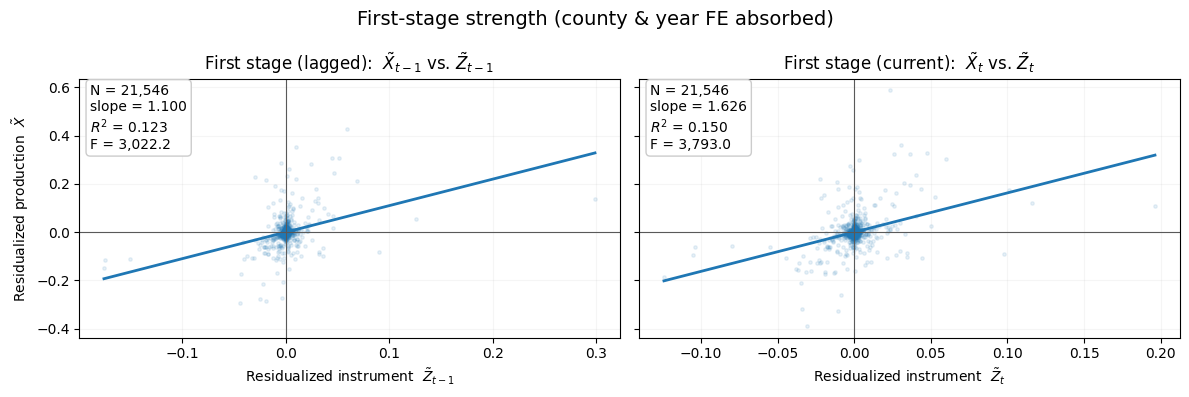

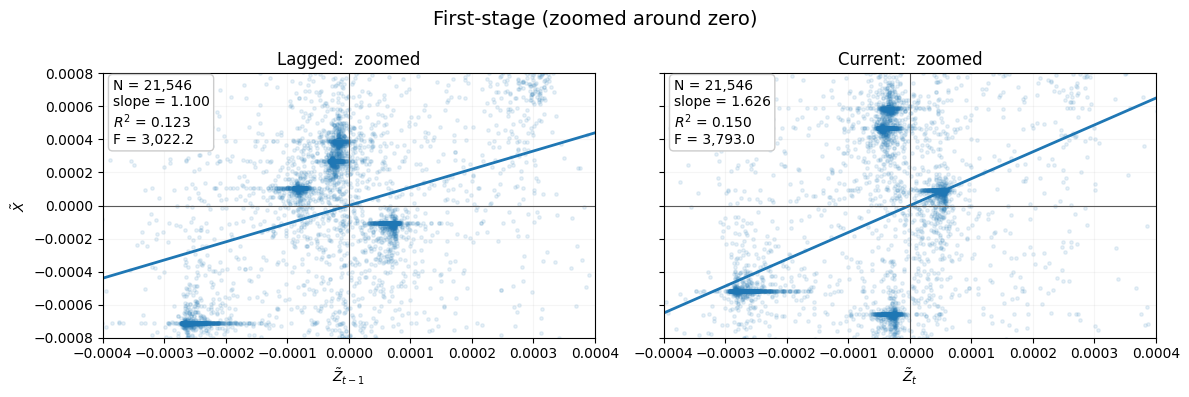

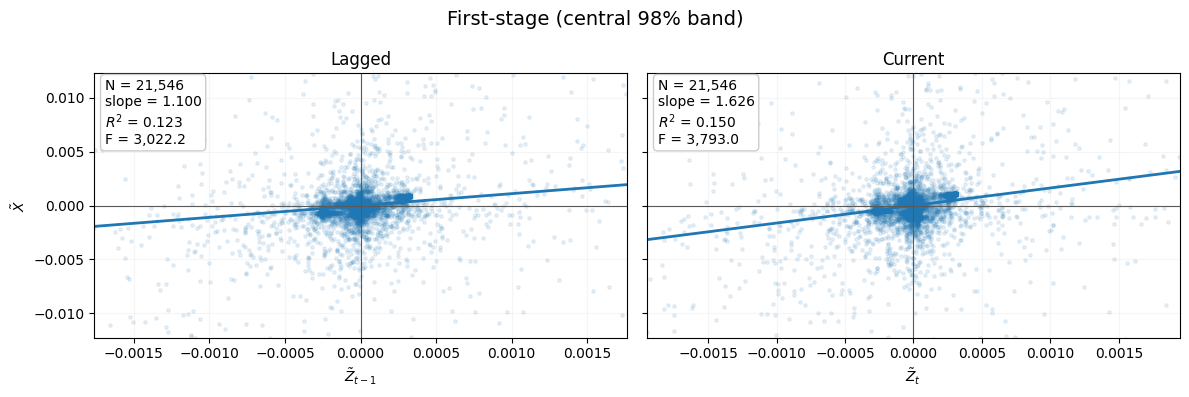

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ FE residualizer ------------------
# Goal: remove county and year FEs from selected columns without creating dummies
# For each county c, subtract the county mean of c, subtract year mean of c, and then add back overall mean
# Groupby(..).transform("mean") gives county specific mean and year specific mean 

def twoway_demean_df(df, entity_col="fips", time_col="year", cols=None):
    if cols is None: cols = df.columns # If you didn't pass a list of columns, then operate on all columns
    out = pd.DataFrame(index=df.index) # Prepare an empty output dataframe with the same index as df
    for c in cols: # Loop through each target column; v is the origina series
        v = df[c]
        out[c] = (
            v
            - df.groupby(entity_col)[c].transform("mean")
            - df.groupby(time_col)[c].transform("mean")
            + v.mean()
        )
    return out # Return the residualized dataframe


# ------------------ First-stage scatter (with zoom) ------------------
# Bivariate first stage plotter
# Plotresdiualized instrument z on x-axis vs. residualized endog regressor x on y-axis, and fit a straight line.

def first_stage_scatter(
    ax, z, x, annotate=True,
    xlim=None, ylim=None,                     # manual limits
    zoom=None,                                # None | "window" | "percentile"
    z_halfwidth=None, x_halfwidth=None,       # for zoom="window"
    pct=0.98                                   # for zoom="percentile" (0–1)
):
    """
    zoom="window":  set xlim=(-z_halfwidth, z_halfwidth), ylim=(-x_halfwidth, x_halfwidth)
    zoom="percentile": set symmetric limits using percentiles of |Z|, |X| (e.g., pct=0.98)
    Or pass explicit xlim/ylim.
    """
    z = np.asarray(z, float); x = np.asarray(x, float) # Convert inputs to clean float arrays to ensure pure numeric math
    m = np.isfinite(z) & np.isfinite(x); z, x = z[m], x[m] # Keep only pairs where both values are finite (drop NaN/inf consistently)

    # raw points
    ax.scatter(z, x, s=6, alpha=0.10, color="#1f77b4") # Plot the raw/residualized points (tiny dots)

    # Plain bivariate OLS of residualized X on reisdualized Z
    zb, xb = z.mean(), x.mean() # Sample means of z and x
    Szz = np.sum((z - zb)**2) # Total variation in Z
    b1  = np.sum((z - zb)*(x - xb)) / Szz # OLS Slope = Cov(Z,X)/Var(Z)
    a   = xb - b1*zb # Intercept

    # This is the first stage slope of X on Z in a simple regression after residualizing X and Z for county and year FE
    grid = np.linspace(z.min(), z.max(), 200)
    ax.plot(grid, a + b1*grid, color="#1f77b4", linewidth=2)

    # Goodness of fit and strength stats
    xhat = a + b1*z # Fitted values
    ssr = np.sum((xhat - xb)**2); sse = np.sum((x - xhat)**2) # Regression sum of squares and Residual sum of squares
    r2 = ssr / (ssr + sse) if (ssr + sse) > 0 else np.nan # Share of variance in X explained by Z
    se_b1 = np.sqrt((sse / max(1, len(z)-2)) / Szz) 
    t = b1 / se_b1; F = t**2 # T stat for null that b1=0, F stat with one regressor (F=t^2).


    if annotate:
        ax.annotate(
            f"N = {len(z):,}\nslope = {b1:,.3f}\n$R^2$ = {r2:,.3f}\nF = {F:,.1f}",
            xy=(0.02, 0.98), xycoords="axes fraction",
            va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8")
        ) # Writes the N, R2, and F into box at top left

    # zoom logic
    if xlim is not None: ax.set_xlim(*xlim)
    if ylim is not None: ax.set_ylim(*ylim)

    if zoom == "window":
        if z_halfwidth is not None: ax.set_xlim(-abs(z_halfwidth), abs(z_halfwidth))
        if x_halfwidth is not None: ax.set_ylim(-abs(x_halfwidth), abs(x_halfwidth))
    elif zoom == "percentile":
        zx = np.quantile(np.abs(z), pct)
        xx = np.quantile(np.abs(x), pct)
        ax.set_xlim(-zx, zx); ax.set_ylim(-xx, xx)

    ax.axhline(0, lw=0.8, color="0.35"); ax.axvline(0, lw=0.8, color="0.35")
    ax.grid(True, alpha=0.12)

# Note that we just did a bivariate OLS on the residualized variables (so FE are abosbred), without 2 way 
    # clustered SEs, and without multiple instruments.

# Formal first stage in the IV (in the later regression table) uses Z and Z_t-1 together and reports a joint F.
    # That joint F will not equal the simple F=t^2 here, and clustered SEs will also change the numbers.
    # The plot here is to visualize a strong first stage, and the formal strength test should come from the multi 
        # instrument first stage with clustered SEs in the following table.

# ---------- Build residualized variables (same as before) ----------
need = [
    "fips","year",
    "newvalue_capita","L1_newvalue_capita",
    "newvalue_capita_ins","L1_newvalue_capita_ins"
] # Columns required from our balanced panel
d = df_bal3[need].dropna().copy() # Subset to those columns and drop rows missing any of them
for c in need:
    if c not in ("fips","year"):
        d[c] = pd.to_numeric(d[c], errors="coerce") # Force numeric types for clean math; drop anything that still became NaN after coercion
d = d.dropna().copy()

dm = twoway_demean_df(
    d, entity_col="fips", time_col="year",
    cols=["newvalue_capita","L1_newvalue_capita","newvalue_capita_ins","L1_newvalue_capita_ins"]
) # Absorb county and year FEs for endogenous regressors and instruments
Xc = dm["newvalue_capita"].to_numpy()
Zc = dm["newvalue_capita_ins"].to_numpy()
Xl = dm["L1_newvalue_capita"].to_numpy()
Zl = dm["L1_newvalue_capita_ins"].to_numpy() # Pull out residualized variables as NumPy arrays for plotting

# ---------- EXAMPLE A: full-range (LAGGED LEFT, CURRENT RIGHT) ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle("First-stage strength (county & year FE absorbed)", fontsize=14)

# Lagged on the LEFT
first_stage_scatter(axes[0], Zl, Xl)
axes[0].set_title(r"First stage (lagged):  $\tilde{X}_{t-1}$ vs. $\tilde{Z}_{t-1}$")
axes[0].set_xlabel(r"Residualized instrument  $\tilde{Z}_{t-1}$")
axes[0].set_ylabel(r"Residualized production  $\tilde{X}$")

# Current on the RIGHT
first_stage_scatter(axes[1], Zc, Xc)
axes[1].set_title(r"First stage (current):  $\tilde{X}_t$ vs. $\tilde{Z}_t$")
axes[1].set_xlabel(r"Residualized instrument  $\tilde{Z}_t$")

plt.tight_layout(); plt.show()


# ---------- EXAMPLE B: zoom near zero (fixed window) ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle("First-stage (zoomed around zero)", fontsize=14)

# Lagged left
first_stage_scatter(
    axes[0], Zl, Xl, zoom="window",
    z_halfwidth=4e-4, x_halfwidth=8e-4
)
axes[0].set_title(r"Lagged:  zoomed"); axes[0].set_xlabel(r"$\tilde{Z}_{t-1}$"); axes[0].set_ylabel(r"$\tilde{X}$")

# Current right
first_stage_scatter(
    axes[1], Zc, Xc, zoom="window",
    z_halfwidth=4e-4, x_halfwidth=8e-4
)
axes[1].set_title(r"Current:  zoomed"); axes[1].set_xlabel(r"$\tilde{Z}_t$")

plt.tight_layout(); plt.show()


# ---------- EXAMPLE C: zoom by percentile bands ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle("First-stage (central 98% band)", fontsize=14)

# Lagged left
first_stage_scatter(axes[0], Zl, Xl, zoom="percentile", pct=0.98)
axes[0].set_title(r"Lagged"); axes[0].set_xlabel(r"$\tilde{Z}_{t-1}$"); axes[0].set_ylabel(r"$\tilde{X}$")

# Current right
first_stage_scatter(axes[1], Zc, Xc, zoom="percentile", pct=0.98)
axes[1].set_title(r"Current"); axes[1].set_xlabel(r"$\tilde{Z}_t$")

plt.tight_layout(); plt.show()

In [8]:
import numpy as np
import pandas as pd
from linearmodels.panel import PooledOLS 
# PooledOLS fits OLS on panel data. We feed it demeaned variables so it is equivalent to FE OLS. 
    # It also supports 2 way clustered SEs.


# =============================================================================
# Two-way demeaning helper (absorbs county & year fixed effects)
# -----------------------------------------------------------------------------
# For each column c, returns:
#   c_it - mean_i(c) - mean_t(c) + grand_mean(c)
# which is algebraically equivalent to including county and year dummies.
# =============================================================================
def twoway_demean_df(df, entity_col="fips", time_col="year", cols=None):
    if cols is None: cols = df.columns
    out = pd.DataFrame(index=df.index)
    for c in cols:
        v = df[c]
        out[c] = (
            v
            - df.groupby(entity_col)[c].transform("mean")
            - df.groupby(time_col)[c].transform("mean")
            + v.mean()
        )
    return out

# =============================================================================
# First-stage tables (manual): after FE absorption, OLS with 2-way clustered SEs
# -----------------------------------------------------------------------------
# We run two first-stage regressions:
#   (1)  X_t     ~ Z_t + Z_{t-1}
#   (2)  X_{t-1} ~ Z_t + Z_{t-1}
#
# Inputs:
#   - df_bal3: balanced county-year panel with columns:
#       fips, year,
#       newvalue_capita (X_t), L1_newvalue_capita (X_{t-1}),
#       newvalue_capita_ins (Z_t), L1_newvalue_capita_ins (Z_{t-1})
#
# Method:
#   - Absorb county & year FE via two-way demeaning on X and Z.
#   - Run PooledOLS(y, X) with cluster_entity=True and cluster_time=True.
#   - Print a tidy coefficient table, R^2, and a joint F-test for instrument set.
# =============================================================================
# Driver that prints the two first stage table (current/lagged shock on current and lagged instruments)
def first_stage_tables_manual(df_bal3):
    """
    Two first stages after absorbing county & year FE:

      (1)  X_t ~ Z_t, Z_{t-1}
      (2)  X_{t-1} ~ Z_t, Z_{t-1}

    Uses PooledOLS with **two-way clustered SEs by entity and time** (no clusters array).
    """
    need = [
        "fips","year",
        "newvalue_capita","L1_newvalue_capita",
        "newvalue_capita_ins","L1_newvalue_capita_ins"
    ]
    d = df_bal3[need].dropna().copy() # Pick out needed cols and drop rows with NAs

    # Absorb FE on X and Z via demeaning 
    dm = twoway_demean_df(
        d, entity_col="fips", time_col="year",
        cols=["newvalue_capita","L1_newvalue_capita",
              "newvalue_capita_ins","L1_newvalue_capita_ins"]
    )
    
    # Builds a working frame with IDs plus the demeaned outcome and instruments
        # Sort and set a (fips, year) multiIndex; PooledOLS uses this to understand entities & time
    def run_one(y_name, Z_names, title):
        w = pd.concat([d[["fips","year"]], dm[[y_name] + Z_names]], axis=1).dropna()
        w = w.sort_values(["fips","year"]).set_index(["fips","year"])

        y = w[y_name]
        X = w[Z_names]

        # Two-way cluster by entity & time using index flags (no clusters array!)
        res = PooledOLS(y, X).fit(
            cov_type="clustered",
            cluster_entity=True,
            cluster_time=True
        ) # Regress y on Z using OLS on demeaned data (equivalent to FE)

        table = pd.DataFrame({
            "coef":       res.params,
            "se (2-way)": res.std_errors,
            "t":          res.tstats,
            "p":          res.pvalues
        }).loc[Z_names].round(4) # Makes a coefficient table 

        r2 = float(getattr(res, "rsquared", np.nan)) # R2 from this first stage regression after FE are absorbed

        # Joint Wald F-test that test both instruments = 0
            # Performs a joint test that all instruments coefficients are 0 (a first stage strength check)
            # Primary route is wald_test, and fallback method if direct method isn't available
        f_txt = "n/a"
        try:
            R = np.eye(len(Z_names))
            wald = res.wald_test(R)
            f_txt = f"{wald.stat:.1f} (p={wald.pval:.4f})"
        except Exception:
            try:
                beta = res.params.values.reshape(-1,1)
                V = res.cov.values
                q = len(Z_names)
                from numpy.linalg import pinv
                F = float(beta.T @ pinv(V) @ beta) / q
                f_txt = f"{F:.1f}"
            except Exception:
                pass

        print(f"\n=== First stage — {title} (FE absorbed; 2-way clustered SEs) ===")
        try:
            display(table)
        except NameError:
            print(table.to_string())
        print(f"R^2: {r2:.3f}   |   Joint F (all Z): {f_txt}")

    # (1) Runs first stage: current shock X_t on (Z_t, Z_{t-1}) 
    run_one(
        y_name="newvalue_capita",
        Z_names=["newvalue_capita_ins","L1_newvalue_capita_ins"],
        title="current shock  X_t  ~  Z_t, Z_{t-1}"
    )

    # (2) Runs first stage: lagged shock X_{t-1} on (Z_t, Z_{t-1})
    run_one(
        y_name="L1_newvalue_capita",
        Z_names=["newvalue_capita_ins","L1_newvalue_capita_ins"],
        title="lagged shock  X_{t-1}  ~  Z_t, Z_{t-1}"
    )

# Run it
first_stage_tables_manual(df_bal3)

#-- Meaning --
# Coefficients: How much X changes when Z moves by one unit (both already residualized for FE)
# SE 2-way: Robust to serial correlation within counties and common year shocks
# R2: Share of variation in X explained by Z, Z lagged, after FE removal
# Joint F: Strength of the instrument set; higher is better (rule of thumb >10)


=== First stage — current shock  X_t  ~  Z_t, Z_{t-1} (FE absorbed; 2-way clustered SEs) ===


,coef,se (2-way),t,p
newvalue_capita_ins,1.5666,0.5346,2.9305,0.0034
L1_newvalue_capita_ins,0.0684,0.4256,0.1608,0.8723


R^2: 0.150   |   Joint F (all Z): 10.1 (p=0.0065)

=== First stage — lagged shock  X_{t-1}  ~  Z_t, Z_{t-1} (FE absorbed; 2-way clustered SEs) ===


,coef,se (2-way),t,p
newvalue_capita_ins,-0.5425,0.2054,-2.6411,0.0083
L1_newvalue_capita_ins,1.4413,0.3818,3.7751,0.0002


R^2: 0.133   |   Joint F (all Z): 18.4 (p=0.0001)
